### Isolation Forest Algorithm

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.ensemble import IsolationForest

warnings.filterwarnings("ignore")

%matplotlib inline

In [3]:
df = pd.read_csv(r'TaxiNYC.csv')
df

,Unnamed: 0,timestamp,value
0,0,2014-07-01 00:00:00,10844
1,1,2014-07-01 00:30:00,8127
2,2,2014-07-01 01:00:00,6210
3,3,2014-07-01 01:30:00,4656
4,4,2014-07-01 02:00:00,3820
...,...,...,...
10315,10315,2015-01-31 21:30:00,24670
10316,10316,2015-01-31 22:00:00,25721
10317,10317,2015-01-31 22:30:00,27309
10318,10318,2015-01-31 23:00:00,26591


In [4]:
df = df.rename(columns={
    "Unnamed: 0":"Unique_ID",
    "value": "passengers"
})

In [5]:
df.drop("Unique_ID",axis=1,inplace=True)

In [6]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')


In [7]:
df.set_index('timestamp', inplace=True)
df

,passengers
timestamp,
2014-07-01 00:00:00,10844
2014-07-01 00:30:00,8127
2014-07-01 01:00:00,6210
2014-07-01 01:30:00,4656
2014-07-01 02:00:00,3820
...,...
2015-01-31 21:30:00,24670
2015-01-31 22:00:00,25721
2015-01-31 22:30:00,27309


In [8]:
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df

,passengers,hour,day_of_week
timestamp,,,
2014-07-01 00:00:00,10844,0,1
2014-07-01 00:30:00,8127,0,1
2014-07-01 01:00:00,6210,1,1
2014-07-01 01:30:00,4656,1,1
2014-07-01 02:00:00,3820,2,1
...,...,...,...
2015-01-31 21:30:00,24670,21,5
2015-01-31 22:00:00,25721,22,5
2015-01-31 22:30:00,27309,22,5


In [9]:
features = df[['passengers', 'hour', 'day_of_week']]

In [10]:
model = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42
)

model.fit(features)

,n_estimators,200
,max_samples,'auto'
,contamination,0.01
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [11]:
df['anomaly'] = model.predict(features)

In [12]:
df

,passengers,hour,day_of_week,anomaly
timestamp,,,,
2014-07-01 00:00:00,10844,0,1,1
2014-07-01 00:30:00,8127,0,1,1
2014-07-01 01:00:00,6210,1,1,1
2014-07-01 01:30:00,4656,1,1,1
2014-07-01 02:00:00,3820,2,1,1
...,...,...,...,...
2015-01-31 21:30:00,24670,21,5,1
2015-01-31 22:00:00,25721,22,5,1
2015-01-31 22:30:00,27309,22,5,1


In [14]:
# 1 = Normal and -1 = Anomaly
df['anomaly'].value_counts()

anomaly
 1    10217
-1      103
Name: count, dtype: int64

In [15]:
# Now 1 = Anomaly and 0 = Normal
df['anomaly'] = df['anomaly'].map({1:0, -1:1})

In [16]:
anomalies = df[df['anomaly'] == 1]

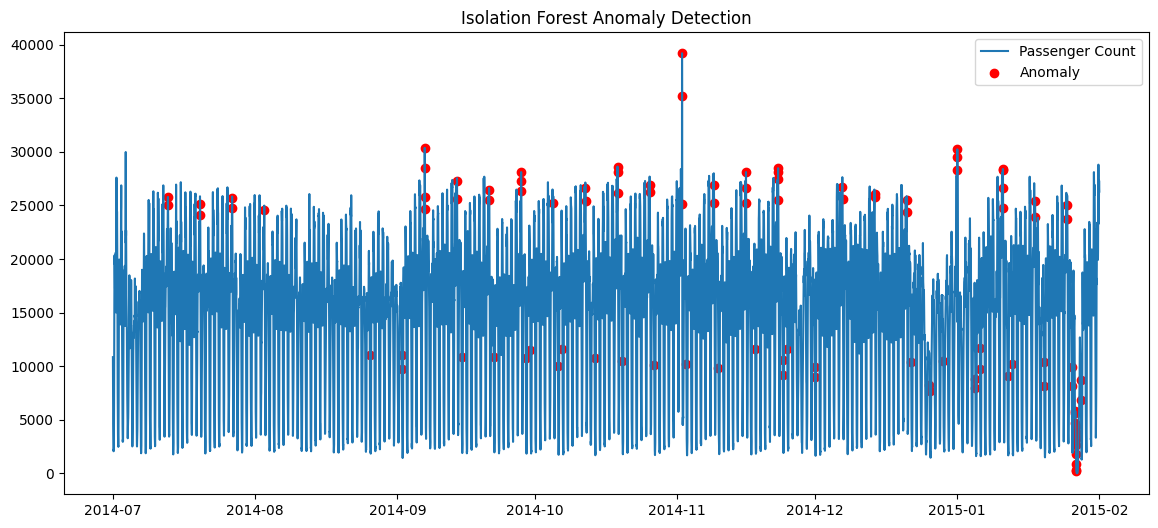

In [17]:
plt.figure(figsize=(14,6))

plt.plot(df.index, df['passengers'], label='Passenger Count')

plt.scatter(
    anomalies.index,
    anomalies['passengers'],
    color='red',
    label='Anomaly'
)

plt.legend()
plt.title("Isolation Forest Anomaly Detection")
plt.show()

In [18]:
print("Number of anomalies detected:", anomalies.shape[0])

Number of anomalies detected: 103
